# **Breast Cancer Classification With Neural Networks**

## Import Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
import warnings
warnings.filterwarnings("ignore")

## Task 1 - Load Dataset

In [5]:
df = load_breast_cancer(as_frame=True)

In [6]:
x = df.data
y = df.target

### - Understanding Dataset

In [8]:
x.shape

(569, 30)

In [9]:
y.value_counts()

target
1    357
0    212
Name: count, dtype: int64

In [10]:
x.describe().round(2)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,...,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00
mean,14.13,19.29,91.97,654.89,0.10,0.10,0.09,0.05,0.18,0.06,...,16.27,25.68,107.26,880.58,0.13,0.25,0.27,0.11,0.29,0.08
std,3.52,4.30,24.30,351.91,0.01,0.05,0.08,0.04,0.03,0.01,...,4.83,6.15,33.60,569.36,0.02,0.16,0.21,0.07,0.06,0.02
min,6.98,9.71,43.79,143.50,0.05,0.02,0.00,0.00,0.11,0.05,...,7.93,12.02,50.41,185.20,0.07,0.03,0.00,0.00,0.16,0.06
25%,11.70,16.17,75.17,420.30,0.09,0.06,0.03,0.02,0.16,0.06,...,13.01,21.08,84.11,515.30,0.12,0.15,0.11,0.06,0.25,0.07
50%,13.37,18.84,86.24,551.10,0.10,0.09,0.06,0.03,0.18,0.06,...,14.97,25.41,97.66,686.50,0.13,0.21,0.23,0.10,0.28,0.08
75%,15.78,21.80,104.10,782.70,0.11,0.13,0.13,0.07,0.20,0.07,...,18.79,29.72,125.40,1084.00,0.15,0.34,0.38,0.16,0.32,0.09
max,28.11,39.28,188.50,2501.00,0.16,0.35,0.43,0.20,0.30,0.10,...,36.04,49.54,251.20,4254.00,0.22,1.06,1.25,0.29,0.66,0.21


## Exploratory Data Analysis (EDA)

### - Class distribution plot 

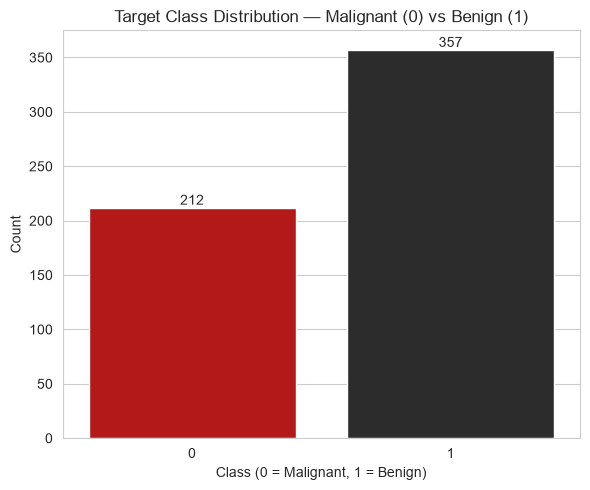

In [13]:
plt.figure(figsize=(6, 5))
sns.set_style('whitegrid')
ax = sns.countplot(x=y, hue=y, palette=['#CC0000', '#2C2C2C'], legend=False)
ax.set_title('Target Class Distribution — Malignant (0) vs Benign (1)')
ax.set_xlabel('Class (0 = Malignant, 1 = Benign)')
ax.set_ylabel('Count')

for p in ax.patches:
    count = int(p.get_height())
    ax.annotate(str(count), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')

plt.tight_layout()
plt.savefig('task1_class_distribution.png')
plt.show()

### - Feature correlation heatmap

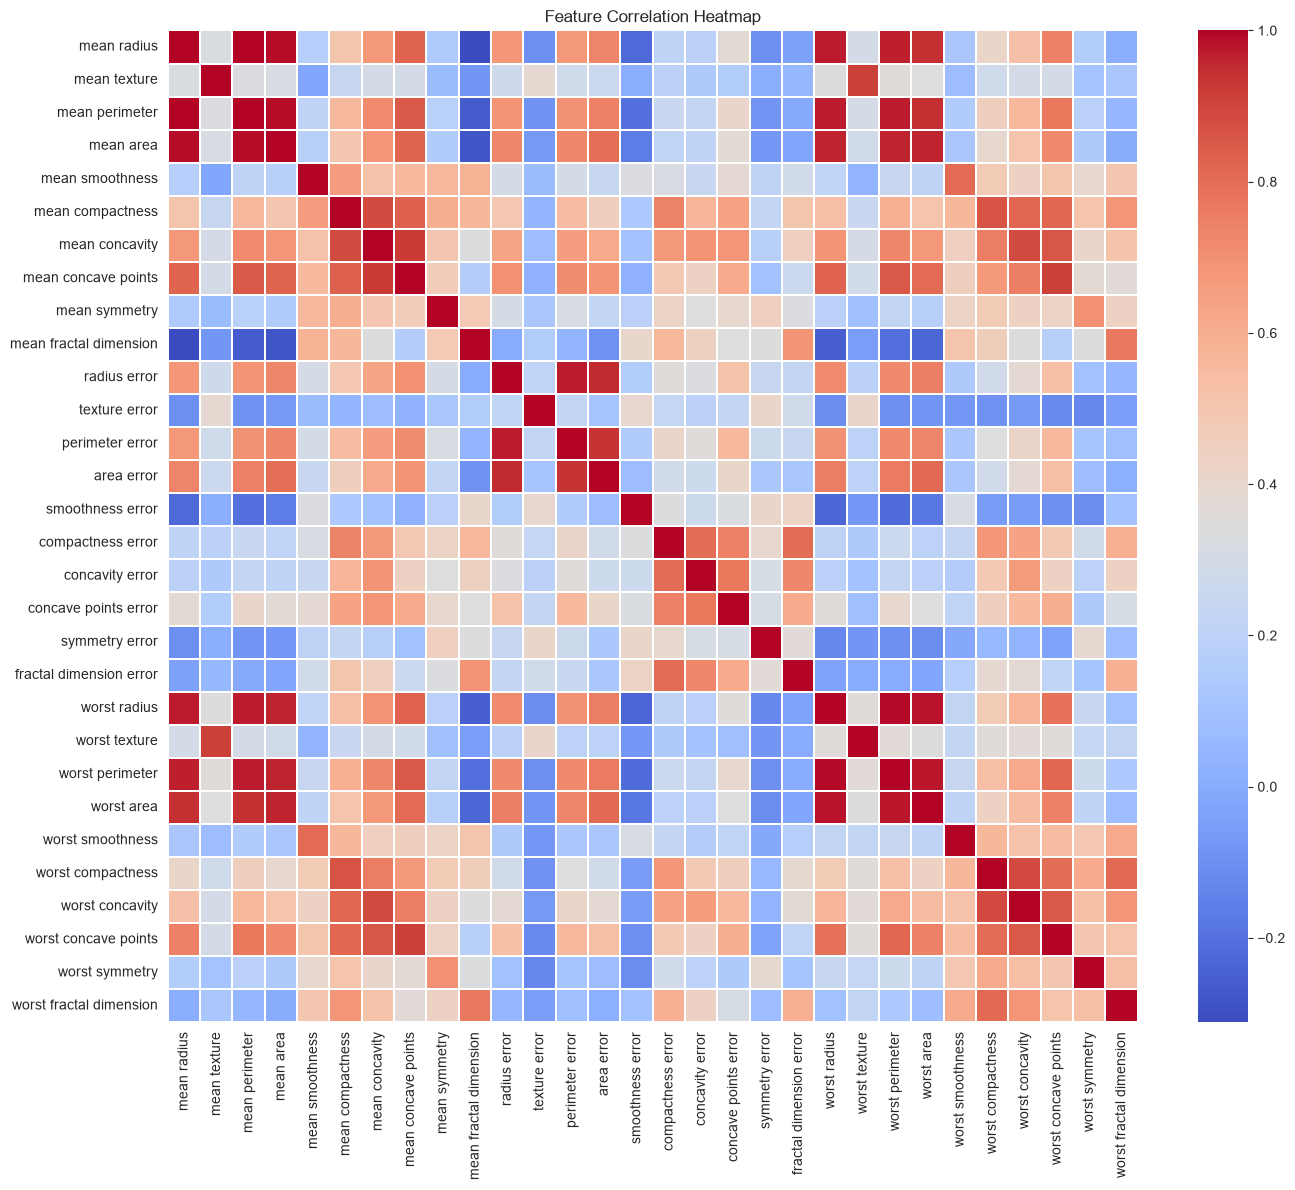

In [15]:
corr_matrix = x.corr()
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.3)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('task1_correlation_heatmap.png')
plt.show()

In [16]:
np.random.seed(42)
tf.random.set_seed(42)

### - Train/Test Split 

In [18]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state=42,stratify=y)

### - StandardScaler 

In [20]:
scaler = StandardScaler()
scaler.fit(x_train)
x_train_sc = scaler.transform(x_train)
x_test_sc = scaler.transform(x_test)

### - Why scaling for neural networks

Neural networks are trained using gradient based optimizers such as SGD and Adam. These optimizers update the model weights step by step based on the size of the gradients.

If some features have a very different scale than others (for example, one feature ranges from 0 to 1000 and another ranges from 0 to 1), the features with a large range can dominate the early updates, while features with a small range have very little influence on learning. This makes training slower and less stable, and the optimizer can struggle to find a good solution.

StandardScaler transforms every feature so that it has a mean of 0 and a standard deviation of 1. This puts all features on a similar scale, which helps the neural network learn more efficiently and converge faster.

## Task 2 - Single Layer Preceptron (SLP) - Baseline Model

### - Build the SLP

In [24]:
model_slp = Sequential()
model_slp.add(Dense(1, activation='sigmoid',input_dim = 30))

In [25]:
model_slp.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 1)                   │              31 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 31 (124.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

### - Compile the SLP

In [27]:
model_slp.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

In [28]:
total_params = model_slp.count_params()
total_params

31

### - Train the SLP

In [30]:
history_slp = model_slp.fit(x_train_sc,y_train,epochs = 50, batch_size = 32, validation_split = 0.1, verbose = 1)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.1980 - loss: 1.3117 - val_accuracy: 0.2174 - val_loss: 1.3645
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2372 - loss: 1.1925 - val_accuracy: 0.2174 - val_loss: 1.2554
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2910 - loss: 1.0840 - val_accuracy: 0.1957 - val_loss: 1.1553
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3472 - loss: 0.9867 - val_accuracy: 0.2174 - val_loss: 1.0649
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4328 - loss: 0.9007 - val_accuracy: 0.3043 - val_loss: 0.9843
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4866 - loss: 0.8256 - val_accuracy: 0.4130 - val_loss: 0.9132
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5477 - loss: 0.7602 - val_accuracy: 0.4783 - val_loss: 0.8508
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6015 - loss: 0.7036 - val_accuracy: 0.5435 - val_loss

### - Plot SLP training curves

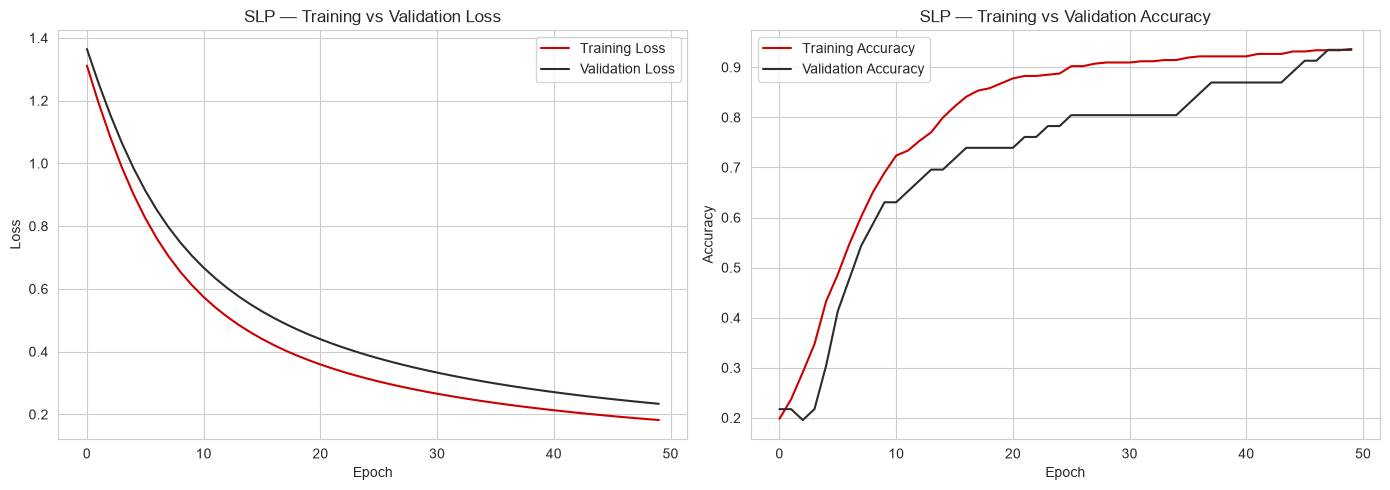

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_slp.history['loss'], label='Training Loss', color='#CC0000')
axes[0].plot(history_slp.history['val_loss'], label='Validation Loss', color='#2C2C2C')
axes[0].set_title('SLP — Training vs Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_slp.history['accuracy'], label='Training Accuracy', color='#CC0000')
axes[1].plot(history_slp.history['val_accuracy'], label='Validation Accuracy', color='#2C2C2C')
axes[1].set_title('SLP — Training vs Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('task2_slp_training_curves.png')
plt.show()


### - Evaluate the SLP

In [34]:
slp_loss,slp_acc = model_slp.evaluate(x_test_sc,y_test,verbose=0)
slp_loss

0.2149692326784134

In [35]:
slp_acc

0.9122806787490845

In [36]:
y_pred_slp = (model_slp.predict(x_test_sc)>0.5).astype(int)
print(classification_report(y_test,y_pred_slp))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
              precision    recall  f1-score   support

           0       0.86      0.90      0.88        42
           1       0.94      0.92      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.91      0.91       114
weighted avg       0.91      0.91      0.91       114



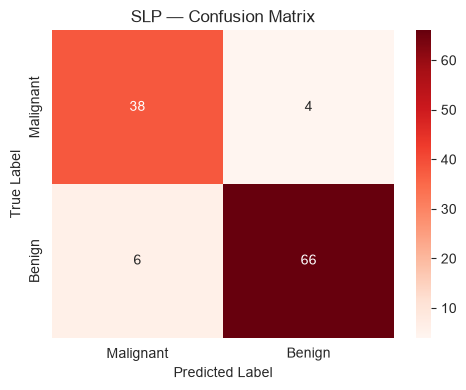

In [37]:
cm_slp = confusion_matrix(y_test, y_pred_slp)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_slp, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'])
plt.title('SLP — Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('task2_slp_confusion_matrix.png')
plt.show()


In [38]:
slp_precision = precision_score(y_test, y_pred_slp)
slp_recall = recall_score(y_test, y_pred_slp)
slp_f1 = f1_score(y_test, y_pred_slp)

results = {}
results['SLP'] = {
    'Architecture': 'Dense(1, sigmoid)',
    'Regularization': 'None',
    'Dropout Rate': 'None',
    'Early Stopping': 'No',
    'Test Accuracy': slp_acc,
    'Test Precision': slp_precision,
    'Test Recall': slp_recall,
    'Test F1-Score': slp_f1
}
results['SLP']


{'Architecture': 'Dense(1, sigmoid)',
 'Regularization': 'None',
 'Dropout Rate': 'None',
 'Early Stopping': 'No',
 'Test Accuracy': 0.9122806787490845,
 'Test Precision': 0.9428571428571428,
 'Test Recall': 0.9166666666666666,
 'Test F1-Score': 0.9295774647887324}

### - SLP limitations 

The SLP has no hidden layer, so it can only learn a linear decision boundary between the two classes. This means it can only properly separate the classes if the data is linearly separable, or close to it. Breast cancer data can contain more complex, non-linear relationships between features, which a single neuron cannot fully capture. Because of this, the SLP is used here only as a simple baseline model. 

## Task 3 -  Multi-Layer Perceptron (MLP) — Activation Functions


### - Build the MLP (ReLU)

In [42]:
model_mlp = Sequential()
model_mlp.add(Dense(64, activation='relu',input_dim = 30))
model_mlp.add(Dense(32, activation='relu'))
model_mlp.add(Dense(1, activation='sigmoid'))

In [43]:
model_mlp.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                      │ (None, 64)                  │           1,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

### - Why hidden layers

Hidden layers allow the model to learn non-linear relationships in the data, which a single layer cannot do. Each Dense layer transforms the input into a new representation. When we stack multiple hidden layers, the network can combine simple patterns from earlier layers into more complex patterns in later layers. The ReLU activation function adds non-linearity between layers, which helps the network learn non-linear relationships instead of just a straight line boundary.

### - Compile and train MLP (ReLU)

In [46]:
model_mlp.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

In [47]:
history_mlp = model_mlp.fit(x_train_sc,y_train,epochs = 100, batch_size = 32, validation_split = 0.1, verbose = 1)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.7897 - loss: 0.5411 - val_accuracy: 0.8696 - val_loss: 0.4592
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9267 - loss: 0.3068 - val_accuracy: 0.8913 - val_loss: 0.3178
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9511 - loss: 0.2006 - val_accuracy: 0.8913 - val_loss: 0.2486
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9609 - loss: 0.1478 - val_accuracy: 0.8913 - val_loss: 0.2063
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9658 - loss: 0.1171 - val_accuracy: 0.9348 - val_loss: 0.1762
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9780 - loss: 0.0970 - val_accuracy: 0.9348 - val_loss: 0.1539
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9804 - loss: 0.0833 - val_accuracy: 0.9565 - val_loss: 0.1344
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9829 - loss: 0.0737 - val_accuracy: 0.9565

### - Compare activation functions

In [49]:
def build_mlp(activation):
    model = keras.Sequential([
        keras.Input(shape=(30,)),
        keras.layers.Dense(64, activation=activation),
        keras.layers.Dense(32, activation=activation),
        keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

activations = ['relu', 'tanh', 'sigmoid']
activation_models = {}
activation_histories = {}

for act in activations:
    model = build_mlp(act)
    history = model.fit(
        x_train_sc,
        y_train,
        epochs=100,
        batch_size=32,
        validation_split=0.1,
        verbose=0
    )
    activation_models[act] = model
    activation_histories[act] = history
    print(act, "training done")

relu training done
tanh training done
sigmoid training done


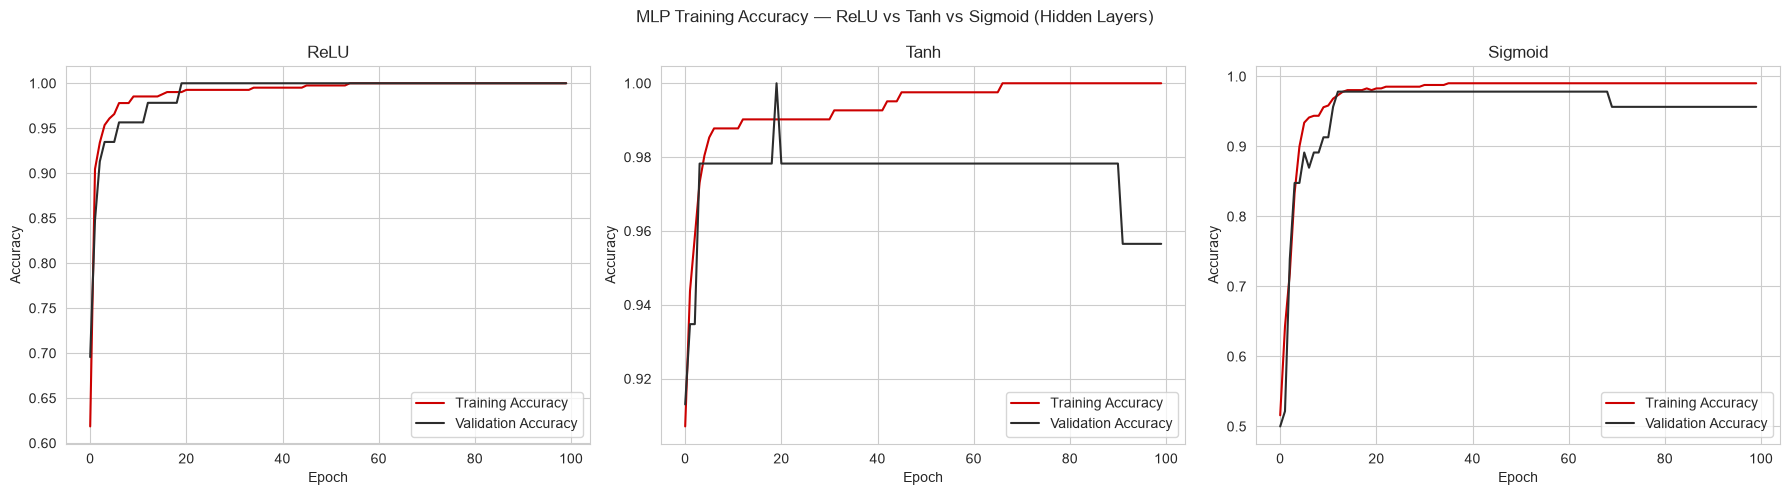

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = {'relu': 'ReLU', 'tanh': 'Tanh', 'sigmoid': 'Sigmoid'}

for ax, act in zip(axes, activations):
    h = activation_histories[act]
    ax.plot(h.history['accuracy'], label='Training Accuracy', color='#CC0000')
    ax.plot(h.history['val_accuracy'], label='Validation Accuracy', color='#2C2C2C')
    ax.set_title(titles[act])
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend()

fig.suptitle('MLP Training Accuracy — ReLU vs Tanh vs Sigmoid (Hidden Layers)')
plt.tight_layout()
plt.savefig('task3_activation_comparison.png')
plt.show()

### - Activation functions

**ReLU**
- Formula: `max(0, x)`
- Fast convergence in many cases.
- Negative inputs have zero gradient.
- Can have dying ReLU problems, where some neurons stop learning.

**Tanh**
- Output range is -1 to 1.
- Zero-centered, which can help optimization.
- Can suffer from vanishing gradients for very large or very small inputs.

**Sigmoid**
- Output range is 0 to 1.
- Not zero-centered.
- Can suffer from strong vanishing gradients when used in hidden layers.
- It is suitable for the final output layer of binary classification


In [52]:
activation_val_acc = {act: activation_histories[act].history['val_accuracy'][-1] for act in activations}
print("Final validation accuracy per activation:")
for act, acc in activation_val_acc.items():
    print(f"{act}: {acc:.4f}")

best_activation = max(activation_val_acc, key=activation_val_acc.get)
print("\nBest activation based on validation accuracy:", best_activation)

Final validation accuracy per activation:
relu: 1.0000
tanh: 0.9565
sigmoid: 0.9565

Best activation based on validation accuracy: relu


### - Evaluate best MLP

In [54]:
best_mlp_model = activation_models[best_activation]

mlp_loss, mlp_acc = best_mlp_model.evaluate(x_test_sc, y_test, verbose=0)
y_pred_mlp = (best_mlp_model.predict(x_test_sc) > 0.5).astype(int)

print("Best activation:", best_activation)
print("Test Accuracy:", mlp_acc)
print(classification_report(y_test, y_pred_mlp))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Best activation: relu
Test Accuracy: 0.9561403393745422
              precision    recall  f1-score   support

           0       0.91      0.98      0.94        42
           1       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



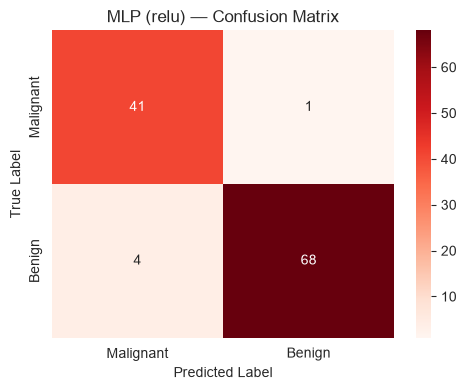

In [55]:
cm_mlp = confusion_matrix(y_test, y_pred_mlp)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'])
plt.title(f'MLP ({best_activation}) — Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('task3_mlp_confusion_matrix.png')
plt.show()

In [56]:
mlp_precision = precision_score(y_test, y_pred_mlp)
mlp_recall = recall_score(y_test, y_pred_mlp)
mlp_f1 = f1_score(y_test, y_pred_mlp)

results[f'MLP-{best_activation}'] = {
    'Architecture': f'Dense(64,{best_activation})-Dense(32,{best_activation})-Dense(1,sigmoid)',
    'Regularization': 'None',
    'Dropout Rate': 'None',
    'Early Stopping': 'No',
    'Test Accuracy': mlp_acc,
    'Test Precision': mlp_precision,
    'Test Recall': mlp_recall,
    'Test F1-Score': mlp_f1
}

print("SLP test accuracy:", slp_acc)
print(f"Best MLP ({best_activation}) test accuracy:", mlp_acc)


SLP test accuracy: 0.9122806787490845
Best MLP (relu) test accuracy: 0.9561403393745422


## Task 4 - Early Stopping

### - Build MLP for Early Stopping

In [59]:
model_es = Sequential()
model_es.add(Dense(128, activation='relu',input_dim = 30))
model_es.add(Dense(64, activation='relu'))
model_es.add(Dense(1, activation='sigmoid'))

In [60]:
model_es.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                     │ (None, 128)                 │           3,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)

In [61]:
model_es.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

### - EarlyStopping Callback

In [63]:
es = EarlyStopping(monitor='val_loss',patience=15,restore_best_weights=True,verbose=1)

In [64]:
history_es = model_es.fit(x_train_sc,y_train,epochs = 300, batch_size = 32, validation_split = 0.1, callbacks = [es],verbose=1)

Epoch 1/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.8949 - loss: 0.4073 - val_accuracy: 0.8913 - val_loss: 0.2756
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9609 - loss: 0.1706 - val_accuracy: 0.9565 - val_loss: 0.1765
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9731 - loss: 0.1079 - val_accuracy: 0.9783 - val_loss: 0.1328
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9756 - loss: 0.0826 - val_accuracy: 0.9783 - val_loss: 0.1039
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9829 - loss: 0.0690 - val_accuracy: 0.9783 - val_loss: 0.0844
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9878 - loss: 0.0607 - val_accuracy: 0.9783 - val_loss: 0.0723
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9878 - loss: 0.0544 - val_accuracy: 0.9783 - val_loss: 0.0646
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9878 - loss: 0.0492 - val_accuracy: 0.97

### - Why Early stopping

- `monitor='val_loss'`: This tells Keras to watch the validation loss after every epoch, since a
  lower validation loss usually means the model is generalizing better to unseen data.
- `patience=15`: This means training will continue for up to 15 more epochs after the last time
  the validation loss improved. If it does not improve during those 15 epochs, training stops.
- `restore_best_weights=True`: When training stops, the model weights are set back to the weights
  from the epoch with the best (lowest) validation loss, not the weights from the very last epoch.
- `verbose=1`: This prints a message when Early Stopping actually stops the training, so we can see
  which epoch it stopped at.


### - Plot Early stopping curves

Training stopped at epoch: 265


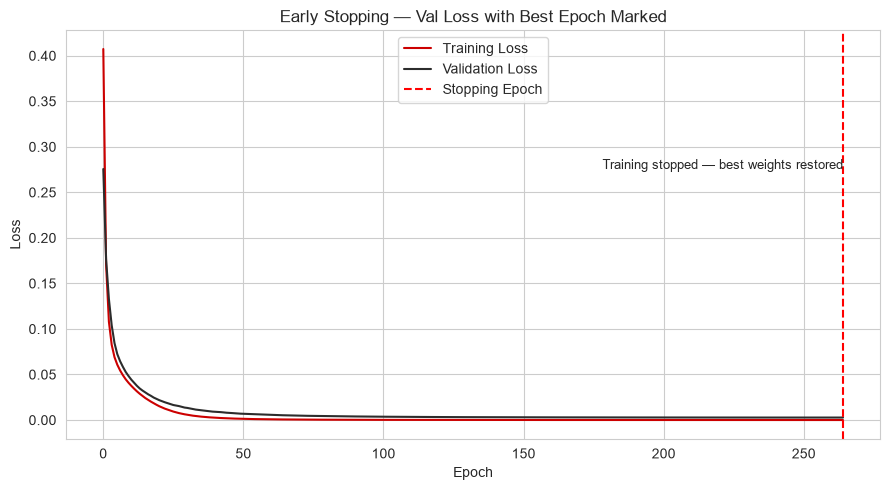

In [67]:
stopping_epoch = len(history_es.history['loss'])
print("Training stopped at epoch:", stopping_epoch)

plt.figure(figsize=(9, 5))
plt.plot(history_es.history['loss'], label='Training Loss', color='#CC0000')
plt.plot(history_es.history['val_loss'], label='Validation Loss', color='#2C2C2C')
plt.axvline(x=stopping_epoch - 1, color='red', linestyle='--', label='Stopping Epoch')
plt.annotate('Training stopped — best weights restored',
             xy=(stopping_epoch - 1, max(history_es.history['val_loss'])),
             xytext=(stopping_epoch - 1, max(history_es.history['val_loss'])),
             ha='right', fontsize=9)
plt.title('Early Stopping — Val Loss with Best Epoch Marked')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.savefig('task4_early_stopping_curve.png')
plt.show()

### - Compare : with vs without Early stopping

In [69]:
model_no_es = keras.Sequential([
    keras.Input(shape=(30,)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model_no_es.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_no_es = model_no_es.fit(
    x_train_sc,
    y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.1,
    verbose=0
)

print("Training without Early Stopping finished, ran for full 300 epochs.")

Training without Early Stopping finished, ran for full 300 epochs.


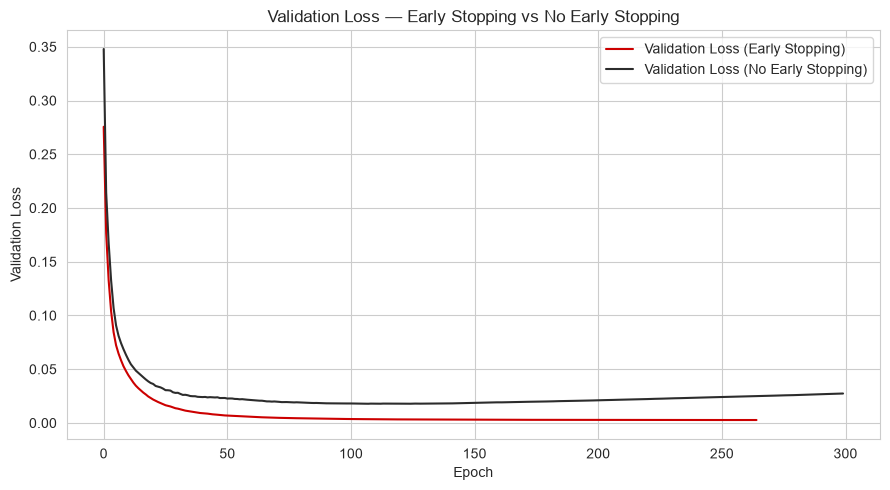

In [70]:
plt.figure(figsize=(9, 5))
plt.plot(history_es.history['val_loss'], label='Validation Loss (Early Stopping)', color='#CC0000')
plt.plot(history_no_es.history['val_loss'], label='Validation Loss (No Early Stopping)', color='#2C2C2C')
plt.title('Validation Loss — Early Stopping vs No Early Stopping')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.legend()
plt.tight_layout()
plt.savefig('task4_es_comparison.png')
plt.show()

In [71]:
es_loss, es_acc = model_es.evaluate(x_test_sc, y_test, verbose=0)
no_es_loss, no_es_acc = model_no_es.evaluate(x_test_sc, y_test, verbose=0)

min_val_loss_no_es = min(history_no_es.history['val_loss'])
min_val_loss_epoch_no_es = int(np.argmin(history_no_es.history['val_loss'])) + 1

print("Early Stopping model — Test Accuracy:", es_acc, "| Test Loss:", es_loss)
print("No Early Stopping model — Test Accuracy:", no_es_acc, "| Test Loss:", no_es_loss)
print()
print("No Early Stopping model reached its lowest validation loss at epoch:", min_val_loss_epoch_no_es)
print("After that epoch, its validation loss trend can be checked in the plot above to see overfitting.")

Early Stopping model — Test Accuracy: 0.9561403393745422 | Test Loss: 0.26744306087493896
No Early Stopping model — Test Accuracy: 0.9561403393745422 | Test Loss: 0.2848305404186249

No Early Stopping model reached its lowest validation loss at epoch: 124
After that epoch, its validation loss trend can be checked in the plot above to see overfitting.


In [72]:
y_pred_es = (model_es.predict(x_test_sc) > 0.5).astype(int)
es_precision = precision_score(y_test, y_pred_es)
es_recall = recall_score(y_test, y_pred_es)
es_f1 = f1_score(y_test, y_pred_es)

results['MLP + Early Stopping'] = {
    'Architecture': 'Dense(128,relu)-Dense(64,relu)-Dense(1,sigmoid)',
    'Regularization': 'None',
    'Dropout Rate': 'None',
    'Early Stopping': 'Yes (patience=15)',
    'Test Accuracy': es_acc,
    'Test Precision': es_precision,
    'Test Recall': es_recall,
    'Test F1-Score': es_f1
}
results['MLP + Early Stopping']

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/stepWARNING:tensorflow:6 out of the last 12 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000001F742B0E020> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


{'Architecture': 'Dense(128,relu)-Dense(64,relu)-Dense(1,sigmoid)',
 'Regularization': 'None',
 'Dropout Rate': 'None',
 'Early Stopping': 'Yes (patience=15)',
 'Test Accuracy': 0.9561403393745422,
 'Test Precision': 0.9855072463768116,
 'Test Recall': 0.9444444444444444,
 'Test F1-Score': 0.9645390070921985}

## Task 5: Dropout Layers

### - Build MLP With Dropout

In [75]:
model_drop = Sequential()
model_drop.add(Dense(128,activation='relu',input_dim = 30))
model_drop.add(Dropout(0.3))
model_drop.add(Dense(64,activation='relu'))
model_drop.add(Dropout(0.3))
model_drop.add(Dense(1,activation='sigmoid'))

In [76]:
model_drop.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_19 (Dense)                     │ (None, 128)                 │           3,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_20 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_21 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)

### - Why Dropout

- Dropout randomly turns off some neuron activations during training.
- `Dropout(0.3)` means approximately 30 percent of activations from the previous layer are dropped
  (set to zero) during each training step.
- This prevents the network from depending too much on any particular neuron, because that neuron
  might not be available in the next step.
- This can reduce overfitting because the network is forced to learn more general, redundant
  patterns instead of memorizing exact training examples.
- During prediction (inference), Dropout is automatically disabled and all neurons are used.


In [78]:
model_drop.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

### - Train Dropout + Early Stopping

In [80]:
es_drop = EarlyStopping(monitor='val_loss',patience=20,restore_best_weights=True,verbose=1)

In [81]:
history_drop = model_drop.fit(x_train_sc,y_train,epochs = 300, batch_size = 32, validation_split = 0.1, callbacks = [es_drop],verbose=1)

Epoch 1/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7653 - loss: 0.5258 - val_accuracy: 0.9130 - val_loss: 0.3588
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9511 - loss: 0.2673 - val_accuracy: 0.9348 - val_loss: 0.2264
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9584 - loss: 0.1586 - val_accuracy: 0.9565 - val_loss: 0.1667
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9633 - loss: 0.1256 - val_accuracy: 0.9783 - val_loss: 0.1312
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9658 - loss: 0.0970 - val_accuracy: 0.9783 - val_loss: 0.1031
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9731 - loss: 0.0781 - val_accuracy: 0.9783 - val_loss: 0.0840
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9804 - loss: 0.0677 - val_accuracy: 0.9783 - val_loss: 0.0720
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9804 - loss: 0.0650 - val_accuracy: 0.9783 - 

### - Effect of Dropout rate

In [83]:
def build_dropout_model(rate):
    model = keras.Sequential([
        keras.Input(shape=(30,)),
        keras.layers.Dense(128, activation='relu'),
        keras.layers.Dropout(rate),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dropout(rate),
        keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

dropout_rates = [0.1, 0.3, 0.5]
dropout_models = {}
dropout_histories = {}

for rate in dropout_rates:
    model = build_dropout_model(rate)
    es_rate = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=0)
    history = model.fit(
        x_train_sc,
        y_train,
        epochs=200,
        batch_size=32,
        validation_split=0.1,
        callbacks=[es_rate],
        verbose=0
    )
    dropout_models[rate] = model
    dropout_histories[rate] = history
    print(f"Dropout {rate} training done, stopped at epoch {len(history.history['loss'])}")

Dropout 0.1 training done, stopped at epoch 56
Dropout 0.3 training done, stopped at epoch 93
Dropout 0.5 training done, stopped at epoch 153


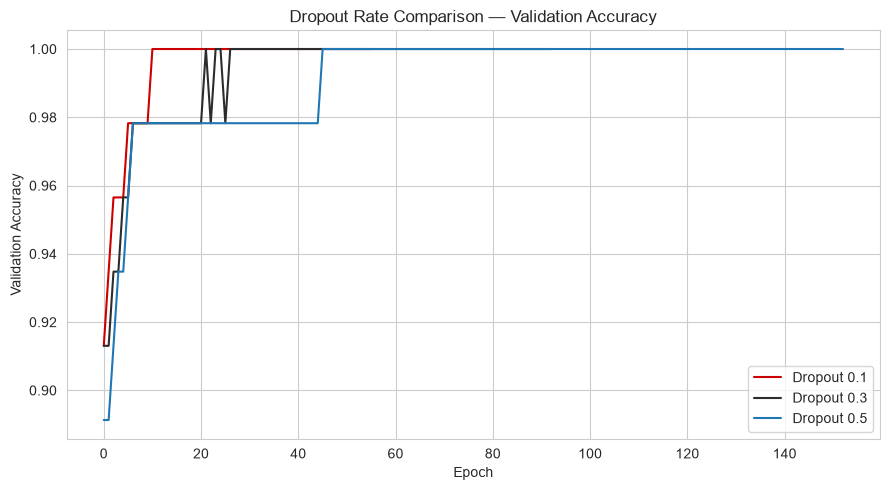

In [84]:
plt.figure(figsize=(9, 5))
colors = {0.1: '#CC0000', 0.3: '#2C2C2C', 0.5: '#1f77b4'}

for rate in dropout_rates:
    plt.plot(dropout_histories[rate].history['val_accuracy'], label=f'Dropout {rate}', color=colors[rate])

plt.title('Dropout Rate Comparison — Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig('task5_dropout_comparison.png')
plt.show()

In [85]:
dropout_val_acc = {rate: max(dropout_histories[rate].history['val_accuracy']) for rate in dropout_rates}
print("Best validation accuracy per dropout rate:")
for rate, acc in dropout_val_acc.items():
    print(f"Dropout {rate}: {acc:.4f}")

best_dropout_rate = max(dropout_val_acc, key=dropout_val_acc.get)
print()
print("Best dropout rate based on validation accuracy:", best_dropout_rate)

Best validation accuracy per dropout rate:
Dropout 0.1: 1.0000
Dropout 0.3: 1.0000
Dropout 0.5: 1.0000

Best dropout rate based on validation accuracy: 0.1


### - Evaluate Dropout model

In [87]:
best_dropout_model = dropout_models[best_dropout_rate]

drop_loss, drop_acc = best_dropout_model.evaluate(x_test_sc, y_test, verbose=0)
y_pred_drop = (best_dropout_model.predict(x_test_sc) > 0.5).astype(int)

drop_precision = precision_score(y_test, y_pred_drop)
drop_recall = recall_score(y_test, y_pred_drop)
drop_f1 = f1_score(y_test, y_pred_drop)

print("Best Dropout rate:", best_dropout_rate)
print("Test Accuracy:", drop_acc)
print("Test Precision:", drop_precision)
print("Test Recall:", drop_recall)
print("Test F1-Score:", drop_f1)

results[f'MLP + Dropout-best ({best_dropout_rate})'] = {
    'Architecture':f'Dense(128,relu)-Dropout({best_dropout_rate})-Dense(64,relu)-Dropout({best_dropout_rate})-Dense(1,sigmoid)',
    'Regularization': 'None',
    'Dropout Rate': best_dropout_rate,
    'Early Stopping': 'Yes (patience=20)',
    'Test Accuracy': drop_acc,
    'Test Precision': drop_precision,
    'Test Recall': drop_recall,
    'Test F1-Score': drop_f1
}

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Best Dropout rate: 0.1
Test Accuracy: 0.9649122953414917
Test Precision: 0.9857142857142858
Test Recall: 0.9583333333333334
Test F1-Score: 0.971830985915493


In [88]:
final_train_acc_drop = dropout_histories[best_dropout_rate].history['accuracy'][-1]
final_val_acc_drop = dropout_histories[best_dropout_rate].history['val_accuracy'][-1]

final_train_acc_mlp = activation_histories[best_activation].history['accuracy'][-1]
final_val_acc_mlp = activation_histories[best_activation].history['val_accuracy'][-1]

print("MLP without Dropout — Train Accuracy:", final_train_acc_mlp, "| Val Accuracy:", final_val_acc_mlp)
print("Gap (no dropout):", round(final_train_acc_mlp - final_val_acc_mlp, 4))
print()
print(f"MLP with Dropout ({best_dropout_rate}) — Train Accuracy:", final_train_acc_drop, "| Val Accuracy:", final_val_acc_drop)
print("Gap (with dropout):", round(final_train_acc_drop - final_val_acc_drop, 4))

MLP without Dropout — Train Accuracy: 1.0 | Val Accuracy: 1.0
Gap (no dropout): 0.0

MLP with Dropout (0.1) — Train Accuracy: 1.0 | Val Accuracy: 1.0
Gap (with dropout): 0.0


## Task 6: Regularization — L1, L2, L1-L2

### - L2 Regularization

In [91]:
model_l2 = Sequential()
model_l2.add(Dense(128,activation='relu',input_dim = 30,kernel_regularizer=regularizers.l2(0.001)))
model_l2.add(Dense(64,activation='relu',kernel_regularizer=regularizers.l2(0.001)))
model_l2.add(Dense(1,activation='sigmoid'))

### - Why L2 Regularization

- L2 regularization adds a penalty to the loss based on the sum of squared weights.
- It encourages the weights to stay small, instead of growing very large.
- Small weights usually create a smoother, simpler decision boundary, which can reduce overfitting.
- If the regularization strength is very large, it can force the weights to be too small, which can
  cause underfitting.
- We used `0.001` as the L2 value, which is the value specified in the assignment.


In [93]:
model_l2.compile(optimizer = "adam", loss = 'binary_crossentropy',metrics = ['accuracy'])

In [94]:
es_l2 = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=0)

In [95]:
history_l2 = model_l2.fit(x_train_sc,y_train,epochs = 300,batch_size=32,validation_split=0.1,callbacks=[es_l2],verbose=0)

### -  L1 Regularization

In [97]:
model_l1 = Sequential()
model_l1.add(Dense(128,activation='relu',input_dim = 30,kernel_regularizer=regularizers.l1(0.001)))
model_l1.add(Dense(64,activation='relu',kernel_regularizer=regularizers.l1(0.001)))
model_l1.add(Dense(1,activation='sigmoid'))

In [98]:
model_l1.compile(optimizer = "adam", loss = 'binary_crossentropy',metrics = ['accuracy'])

In [99]:
es_l1 = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=0)

In [100]:
history_l1 = model_l1.fit(x_train_sc,y_train,epochs = 300,batch_size=32,validation_split=0.1,callbacks=[es_l1],verbose=0)

### - L1-L2 Regularization

In [102]:
model_l1l2 = Sequential()
model_l1l2.add(Dense(128,activation='relu',input_dim = 30,kernel_regularizer=regularizers.l1_l2(l1=0.0001, l2=0.001)))
model_l1l2.add(Dense(64,activation='relu',kernel_regularizer=regularizers.l1_l2(l1=0.0001, l2=0.001)))
model_l1l2.add(Dense(1,activation='sigmoid'))

In [103]:
model_l1l2.compile(optimizer = "adam", loss = 'binary_crossentropy',metrics = ['accuracy'])

In [104]:
es_l1l2 = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=0)

In [105]:
history_l1l2 = model_l1l2.fit(x_train_sc,y_train,epochs = 300,batch_size=32,validation_split=0.1,callbacks=[es_l1l2],verbose=0)

### - Regularization Comparison Plot

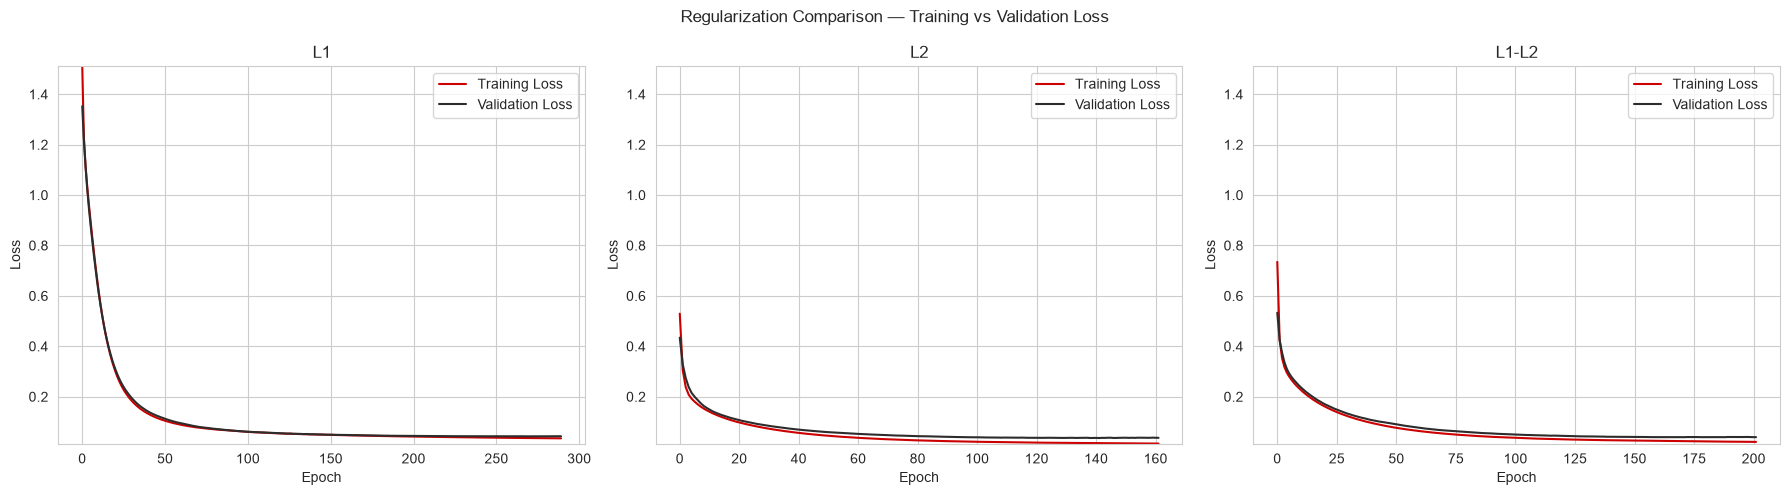

In [107]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

reg_histories = {'L1': history_l1, 'L2': history_l2, 'L1-L2': history_l1l2}

all_losses = []
for h in reg_histories.values():
    all_losses.extend(h.history['loss'])
    all_losses.extend(h.history['val_loss'])
y_min, y_max = min(all_losses), max(all_losses)

for ax, (name, h) in zip(axes, reg_histories.items()):
    ax.plot(h.history['loss'], label='Training Loss', color='#CC0000')
    ax.plot(h.history['val_loss'], label='Validation Loss', color='#2C2C2C')
    ax.set_title(name)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_ylim(y_min, y_max)
    ax.legend()

fig.suptitle('Regularization Comparison — Training vs Validation Loss')
plt.tight_layout()
plt.savefig('task6_regularization_comparison.png')
plt.show()

In [108]:
for name, h in reg_histories.items():
    gap = h.history['loss'][-1] - h.history['val_loss'][-1]
    final_val_acc = h.history['val_accuracy'][-1]
    print(f"{name}: final train-val loss gap = {gap:.4f}, final val accuracy = {final_val_acc:.4f}")

L1: final train-val loss gap = -0.0082, final val accuracy = 1.0000
L2: final train-val loss gap = -0.0228, final val accuracy = 0.9783
L1-L2: final train-val loss gap = -0.0188, final val accuracy = 1.0000


### - Evaluate All Regularized Models

In [110]:
def evaluate_model(model, name):
    loss, acc = model.evaluate(x_test_sc, y_test, verbose=0)
    y_pred = (model.predict(x_test_sc, verbose=0) > 0.5).astype(int)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    print(f"{name}: acc={acc:.4f} precision={precision:.4f} recall={recall:.4f} f1={f1:.4f}")
    return acc, precision, recall, f1

l1_acc, l1_precision, l1_recall, l1_f1 = evaluate_model(model_l1, 'L1')
l2_acc, l2_precision, l2_recall, l2_f1 = evaluate_model(model_l2, 'L2')
l1l2_acc, l1l2_precision, l1l2_recall, l1l2_f1 = evaluate_model(model_l1l2, 'L1-L2')

L1: acc=0.9649 precision=0.9857 recall=0.9583 f1=0.9718
L2: acc=0.9561 precision=0.9855 recall=0.9444 f1=0.9645
L1-L2: acc=0.9561 precision=0.9855 recall=0.9444 f1=0.9645


In [111]:
results['MLP + L1'] = {
    'Architecture': 'Dense(128,relu,L1)-Dense(64,relu,L1)-Dense(1,sigmoid)',
    'Regularization': 'L1 (0.001)',
    'Dropout Rate': 'None',
    'Early Stopping': 'Yes (patience=20)',
    'Test Accuracy': l1_acc, 'Test Precision': l1_precision, 'Test Recall': l1_recall, 'Test F1-Score': l1_f1
}

results['MLP + L2'] = {
    'Architecture': 'Dense(128,relu,L2)-Dense(64,relu,L2)-Dense(1,sigmoid)',
    'Regularization': 'L2 (0.001)',
    'Dropout Rate': 'None',
    'Early Stopping': 'Yes (patience=20)',
    'Test Accuracy': l2_acc, 'Test Precision': l2_precision, 'Test Recall': l2_recall, 'Test F1-Score': l2_f1
}

results['MLP + L1-L2'] = {
    'Architecture': 'Dense(128,relu,L1L2)-Dense(64,relu,L1L2)-Dense(1,sigmoid)',
    'Regularization': 'L1 (0.0001) + L2 (0.001)',
    'Dropout Rate': 'None',
    'Early Stopping': 'Yes (patience=20)',
    'Test Accuracy': l1l2_acc, 'Test Precision': l1l2_precision, 'Test Recall': l1l2_recall, 'Test F1-Score': l1l2_f1
}

bar_data = pd.DataFrame({
    'Model': ['No Regularization', 'L1', 'L2', 'L1-L2'],
    'Test Accuracy': [mlp_acc, l1_acc, l2_acc, l1l2_acc]
})
bar_data


,Model,Test Accuracy
0,No Regularization,0.956140
1,L1,0.964912
2,L2,0.956140
3,L1-L2,0.956140


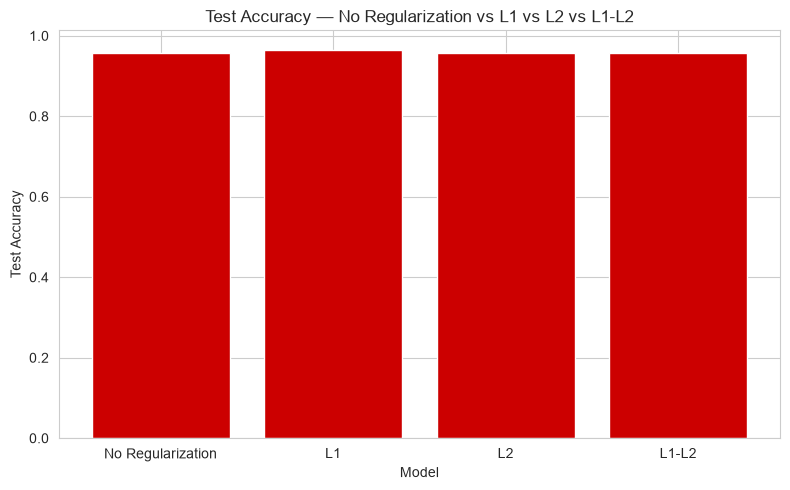

In [112]:
plt.figure(figsize=(8, 5))
plt.bar(bar_data['Model'], bar_data['Test Accuracy'], color='#CC0000')
plt.title('Test Accuracy — No Regularization vs L1 vs L2 vs L1-L2')
plt.xlabel('Model')
plt.ylabel('Test Accuracy')
plt.tight_layout()
plt.savefig('task6_regularization_bar_chart.png')
plt.show()

## Task 7: Final Comparison, Business Insights & Notebook Quality

### - Best model: Combine Dropout + L2 + Early stopping

In [115]:
model_final = Sequential()
model_final.add(Dense(128,activation='relu',input_dim = 30,kernel_regularizer=regularizers.l2(0.001)))
model_final.add(Dropout(0.3))
model_final.add(Dense(64,activation='relu',kernel_regularizer=regularizers.l2(0.001)))
model_final.add(Dropout(0.3))
model_final.add(Dense(1,activation='sigmoid'))

In [116]:
model_final.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

In [117]:
es_final = EarlyStopping(monitor='val_loss',patience=20, restore_best_weights=True,verbose=1)

In [118]:
history_final = model_final.fit(x_train_sc,y_train,epochs = 300, batch_size=32, validation_split=0.1, callbacks=[es_final],verbose=1)

Epoch 1/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.8093 - loss: 0.6061 - val_accuracy: 0.8696 - val_loss: 0.4477
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9462 - loss: 0.3524 - val_accuracy: 0.9565 - val_loss: 0.3322
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9609 - loss: 0.2688 - val_accuracy: 0.9565 - val_loss: 0.2792
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9707 - loss: 0.2290 - val_accuracy: 0.9565 - val_loss: 0.2435
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9707 - loss: 0.2168 - val_accuracy: 0.9783 - val_loss: 0.2184
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9804 - loss: 0.1995 - val_accuracy: 0.9783 - val_loss: 0.2000
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9853 - loss: 0.1865 - val_accuracy: 0.9783 - val_loss: 0.1903
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9878 - loss: 0.1742 - val_accuracy: 0.9783 

In [119]:
final_loss, final_acc = model_final.evaluate(x_test_sc, y_test, verbose=0)
y_pred_final = (model_final.predict(x_test_sc) > 0.5).astype(int)

final_precision = precision_score(y_test, y_pred_final)
final_recall = recall_score(y_test, y_pred_final)
final_f1 = f1_score(y_test, y_pred_final)

print("Final Combined Model — Test Accuracy:", final_acc)
print(classification_report(y_test, y_pred_final))

results['Final Combined Model'] = {
    'Architecture': 'Dense(128,relu,L2)-Dropout(0.3)-Dense(64,relu,L2)-Dropout(0.3)-Dense(1,sigmoid)',
    'Regularization': 'L2 (0.001)',
    'Dropout Rate': 0.3,
    'Early Stopping': 'Yes (patience=20)',
    'Test Accuracy': final_acc,
    'Test Precision': final_precision,
    'Test Recall': final_recall,
    'Test F1-Score': final_f1
}

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Final Combined Model — Test Accuracy: 0.9561403393745422
              precision    recall  f1-score   support

           0       0.91      0.98      0.94        42
           1       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



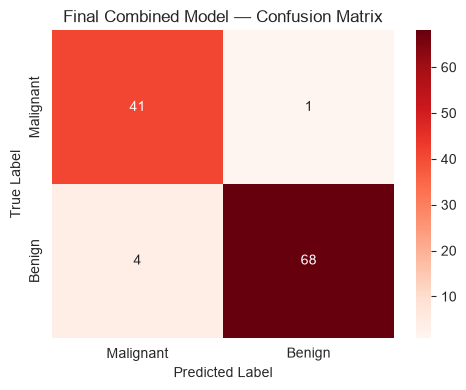

In [120]:
cm_final = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'])
plt.title('Final Combined Model — Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('task7_final_model_confusion_matrix.png')
plt.show()

### -  Full Results Comparison Table

In [122]:
results_df = pd.DataFrame.from_dict(results, orient='index')
results_df.index.name = 'Model'
results_df = results_df.reset_index()
results_df = results_df[['Model', 'Architecture', 'Regularization', 'Dropout Rate',
                          'Early Stopping', 'Test Accuracy', 'Test Precision',
                          'Test Recall', 'Test F1-Score']]
results_df

,Model,Architecture,Regularization,Dropout Rate,Early Stopping,Test Accuracy,Test Precision,Test Recall,Test F1-Score
0,SLP,"Dense(1, sigmoid)",None,None,No,0.912281,0.942857,0.916667,0.929577
1,MLP-relu,"Dense(64,relu)-Dense(32,relu)-Dense(1,sigmoid)",None,None,No,0.956140,0.985507,0.944444,0.964539
2,MLP + Early Stopping,"Dense(128,relu)-Dense(64,relu)-Dense(1,sigmoid)",None,None,Yes (patience=15),0.956140,0.985507,0.944444,0.964539
3,MLP + Dropout-best (0.1),"Dense(128,relu)-Dropout(0.1)-Dense(64,relu)-Dr...",None,0.1,Yes (patience=20),0.964912,0.985714,0.958333,0.971831
4,MLP + L1,"Dense(128,relu,L1)-Dense(64,relu,L1)-Dense(1,s...",L1 (0.001),None,Yes (patience=20),0.964912,0.985714,0.958333,0.971831
5,MLP + L2,"Dense(128,relu,L2)-Dense(64,relu,L2)-Dense(1,s...",L2 (0.001),None,Yes (patience=20),0.956140,0.985507,0.944444,0.964539
6,MLP + L1-L2,"Dense(128,relu,L1L2)-Dense(64,relu,L1L2)-Dense...",L1 (0.0001) + L2 (0.001),None,Yes (patience=20),0.956140,0.985507,0.944444,0.964539
7,Final Combined Model,"Dense(128,relu,L2)-Dropout(0.3)-Dense(64,relu,...",L2 (0.001),0.3,Yes (patience=20),0.956140,0.985507,0.944444,0.964539


In [123]:
results_df.style.highlight_max(
    subset=['Test Accuracy', 'Test F1-Score'],
    color='#ffcccc'
)

,Model,Architecture,Regularization,Dropout Rate,Early Stopping,Test Accuracy,Test Precision,Test Recall,Test F1-Score
0,SLP,"Dense(1, sigmoid)",None,None,No,0.912281,0.942857,0.916667,0.929577
1,MLP-relu,"Dense(64,relu)-Dense(32,relu)-Dense(1,sigmoid)",None,None,No,0.956140,0.985507,0.944444,0.964539
2,MLP + Early Stopping,"Dense(128,relu)-Dense(64,relu)-Dense(1,sigmoid)",None,None,Yes (patience=15),0.956140,0.985507,0.944444,0.964539
3,MLP + Dropout-best (0.1),"Dense(128,relu)-Dropout(0.1)-Dense(64,relu)-Dropout(0.1)-Dense(1,sigmoid)",None,0.100000,Yes (patience=20),0.964912,0.985714,0.958333,0.971831
4,MLP + L1,"Dense(128,relu,L1)-Dense(64,relu,L1)-Dense(1,sigmoid)",L1 (0.001),None,Yes (patience=20),0.964912,0.985714,0.958333,0.971831
5,MLP + L2,"Dense(128,relu,L2)-Dense(64,relu,L2)-Dense(1,sigmoid)",L2 (0.001),None,Yes (patience=20),0.956140,0.985507,0.944444,0.964539
6,MLP + L1-L2,"Dense(128,relu,L1L2)-Dense(64,relu,L1L2)-Dense(1,sigmoid)",L1 (0.0001) + L2 (0.001),None,Yes (patience=20),0.956140,0.985507,0.944444,0.964539
7,Final Combined Model,"Dense(128,relu,L2)-Dropout(0.3)-Dense(64,relu,L2)-Dropout(0.3)-Dense(1,sigmoid)",L2 (0.001),0.300000,Yes (patience=20),0.956140,0.985507,0.944444,0.964539


### - Business insight report

In [125]:
print("Test accuracy summary for generalization techniques:")
print("MLP (no regularization):", mlp_acc)
print("MLP + Early Stopping:", es_acc)
print("MLP + Dropout (best rate", best_dropout_rate, "):", drop_acc)
print("MLP + L2:", l2_acc)
print("MLP + L1:", l1_acc)
print("MLP + L1-L2:", l1l2_acc)
print("Final Combined Model (Dropout + L2 + Early Stopping):", final_acc)


Test accuracy summary for generalization techniques:
MLP (no regularization): 0.9561403393745422
MLP + Early Stopping: 0.9561403393745422
MLP + Dropout (best rate 0.1 ): 0.9649122953414917
MLP + L2: 0.9561403393745422
MLP + L1: 0.9649122953414917
MLP + L1-L2: 0.9561403393745422
Final Combined Model (Dropout + L2 + Early Stopping): 0.9561403393745422
